In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import linalg as la
from scipy.integrate import solve_ivp, solve_bvp
import model

In [2]:
# define a model and timescale
# global variables
const_u1 = 0.

PARAMS = {
    "α": 0.000035,
    "β": 0.003
}

INITIAL_X = np.array([475, 25, 0])

INITIAL_u2guess = np.array([1])

Qmult = 1
Rmult = 1

finite = False

In [3]:
tf = 1000
tsteps = 10001
tspan = np.linspace(0, tf, tsteps)

mod = model.Model(
    seasonal=False,
    params=PARAMS,
    const_u1=const_u1,
    no_dead=True
)

Qbase = np.array([[0, 0, 0],
            [0, 1, 0],
            [0, 0, 0]])    # cost of frog death

Rbase = np.eye(1)   # cost of control

Q = Qbase * Qmult
R = Rbase * Rmult

In [4]:
def get_u_infinite(A, B, x, Q, R):
    '''
    Solve for control given a linearized system
    x_dot = Ax + Bu
    x - state conditions (or last value or previous solution to linearized system)
    '''

    # solve continuous algebraic Riccati equation to get P
    P = la.solve_continuous_are(A, B, Q, R)

    u = - np.linalg.inv(R) @ B.T @ P @ x  # control

    return u

def get_u_finite(A, B, x, Q, R, tcurr, tfinal, m=0):
    '''
    Solve for control given a linearized system
    x_dot = Ax + Bu
    x - state conditions (or last value or previous solution to linearized system)
    '''
    t_steps = 100
    t_space = np.linspace(tcurr, tf, t_steps)

    def P_evolve(t, p): # riccatti ode
        P = p.reshape(A.shape[0], A.shape[0])
        # print("P", P, "\nA", A, "\nB", B, "\nQ", Q, "\nR", R)
        return (-P @ A - A.T @ P - Q + P @ B @ np.linalg.inv(R) @ B.T @ P).flatten()
    
    pf = np.diag([0, m, 0]).flatten()
    #pf = np.zeros(A.shape[0]**2) # P(t_f) = M = 0
    sol_P = solve_ivp(P_evolve, [tfinal, tcurr], pf, dense_output=True, t_eval=t_space[::-1])
    p = sol_P.y
    P = p.reshape(sol_P.t.shape[0], A.shape[0], A.shape[0])[::-1]

    u = - np.linalg.inv(R) @ B.T @ P[0] @ x  # solve for control

    return u


In [5]:
def combinestate(x, u):
    return np.concatenate(x, u)

def breakstate(y):
    return y[:3], y[-1]

def control(t, x, uprev, Q, R, tfinal, finite=False):
    "Get the appropriate control using a previous guess"
    A = mod.f_x(t, x, uprev)
    B = mod.f_u(t, x, uprev)
    if not finite:
        return get_u_infinite(A, B, x, Q, R)
    else:
        return get_u_finite(A, B, x, Q, R, t, tfinal)

def evolvex(t, x, u):
    "Evolve the system"
    # print("Evolving")
    # print(t, x, u)
    # print(mod.f(t, x, u))
    return mod.f(t, x, u)


def uroot(t, x, u, Q, R, tf, finite=False):
    """Returns the value of u"""
    # we want u 

In [10]:
def solvelqr(uinit, xinit, Q, R, tf, finite=False, uupdateshrink=0.5):
    """Solve LQR"""
    constusteps = 10
    tspan_steps = [tspan[tidx:min(tsteps-1, tidx+constusteps)+1] for tidx in np.arange(0, tsteps-1, constusteps)]

    u = [uinit]
    x = INITIAL_X

    tvals = list()
    xvals = list()
    uvals = list()

    for steps in tspan_steps:
        t = steps[0]
        # update u based on current state and previous u value
        
        unewprop = control(t, x, u, Q, R, tf, finite=finite)
        u = (uupdateshrink * (unewprop-u)) + u
        # u = control(t, x, u, Q, R, tf, finite=finite)
        # possibly use newton's method?

        # update t, u, x
        tvals.append(t)
        xvals.append(x)
        uvals.append(u)

        # print(evolvex(
        #     t,
        #     x,
        #     u,
        # ))
        
        # solve on each interval, fixing u
        tspn = (steps[0], steps[-1])
        sol = solve_ivp(
            evolvex,
            tspn,
            x,
            args=(u,),
            t_eval=np.linspace(*tspn, 100)
        )

        x = sol.y[:, -1]

    return np.array(tvals), np.stack(xvals), np.array(uvals) 


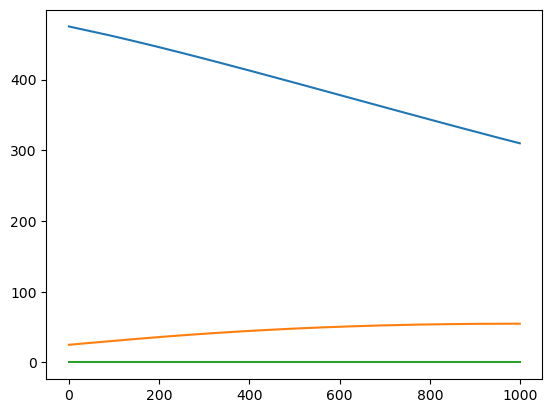

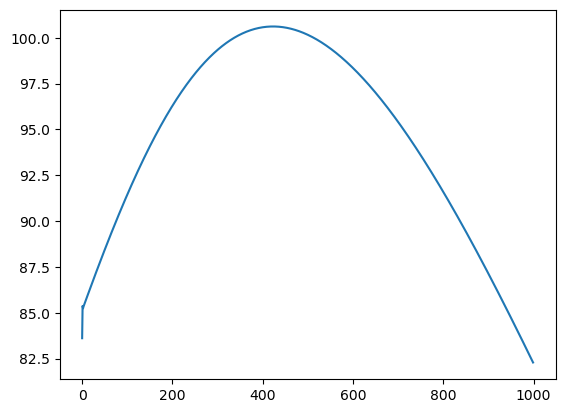

In [27]:
ts, xs, us = solvelqr(100, INITIAL_X, Q, 1*R, tf, finite=False)
plt.plot(ts, xs)
plt.show()
plt.plot(ts, us)
plt.show()

In [ ]:
def costben(uinit, xinit, Q, R, tf, finite=False, uupdateshrink=0.5):
    ts, xs, us = solvelqr(uinit, xinit, Q, R, tf, finite=finite, uupdateshrink=uupdateshrink)
    # plt.plot(ts, xs)
    # plt.show()
    # plt.plot(ts, us)
    # plt.show()
    return xs[-1], (const_u1 * tf) + (np.sum(us) * len(us) / tf)

def costbensweep():
    finalxs = list()
    totalcosts = list()

    for Rmult in np.logspace(-3, 3, 15, base=10):
        finalx, totalcost = costben(100, INITIAL_X, Q, Rmult * Rbase, tf, finite=False)
        finalxs.append(finalx)
        totalcosts.append(totalcost)

    xvals = np.stack(finalxs)
    totalcosts = np.array(totalcosts)
    survived = np.sum(xvals, axis=1)

    return totalcosts, survived


<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_805228/236086772.py:2: SyntaxWarning: invalid escape sequence '\$'
  plt.xlabel("\$ Spent")


Text(0.5, 1.0, 'Cost-benefit Analysis:\nVarying $Q$, $u_1$ in infinite-horizon ILQR')

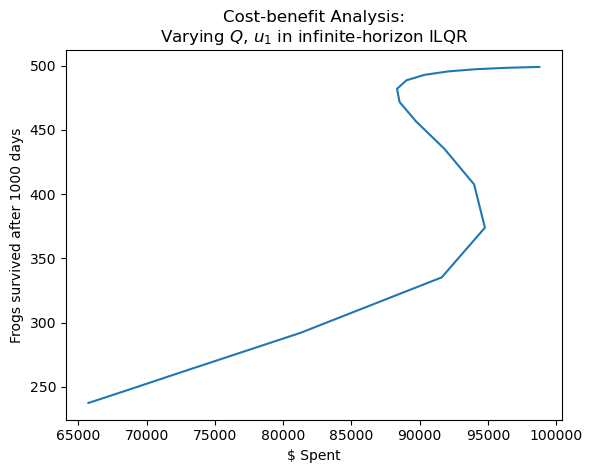

In [ ]:
plt.plot(*costbensweep())
plt.xlabel("$\$$ Spent")
plt.ylabel("Frogs survived after 1000 days")
plt.title("Cost-benefit Analysis:\nVarying $Q$, $u_1$ in infinite-horizon ILQR")

In [38]:
finalxs = list()
totalcosts = list()

for Rmult in np.logspace(-3, 3, 15, base=10):
    finalx, totalcost = costben(100, INITIAL_X, Q, Rmult * Rbase, tf, finite=False)
    finalxs.append(finalx)
    totalcosts.append(totalcost)

In [39]:
xvals = np.stack(finalxs)
display(xvals)

array([[488.63638003,   2.24844901,   0.        ],
       [482.15351963,   3.64036958,   0.        ],
       [472.18370693,   5.85520184,   0.        ],
       [457.14735143,   9.3239658 ,   0.        ],
       [435.17283252,  14.64458098,   0.        ],
       [404.47636433,  22.66039033,   0.        ],
       [363.60249071,  34.84517195,   0.        ],
       [309.86545542,  54.81696823,   0.        ],
       [233.14442688,  93.0620735 ,   0.        ],
       [133.12196021, 151.67379567,   0.        ],
       [ 81.69611233, 175.58248073,   0.        ],
       [ 64.30670787, 180.84056647,   0.        ],
       [ 58.05566246, 182.19587513,   0.        ],
       [ 55.68319121, 182.62342852,   0.        ],
       [ 54.76066563, 182.77662019,   0.        ]])

In [40]:
totalcosts = np.array(totalcosts)

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_805228/264381654.py:3: SyntaxWarning: invalid escape sequence '\$'
  plt.xlabel("\$ Spent")


Text(0.5, 1.0, 'Cost-benefit Analysis:\nVarying $Q$, $u_1$ in infinite-horizon LQR')

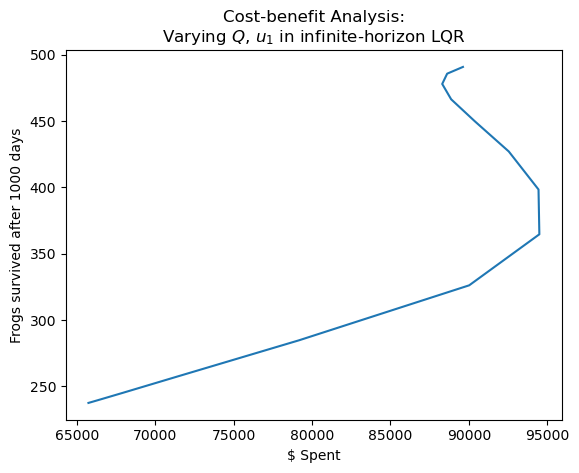

In [47]:
survived = np.sum(xvals, axis=1)
plt.plot(totalcosts, survived)
plt.xlabel("\$ Spent")
plt.ylabel("Frogs survived after 1000 days")
plt.title("Cost-benefit Analysis:\nVarying $Q$, $u_1$ in infinite-horizon LQR")

In [ ]:
# now try to solve LQR
# break up into time intervals
constusteps = 10
tspan_steps = [tspan[tidx:min(tsteps-1, tidx+constusteps)+1] for tidx in np.arange(0, tsteps-1, constusteps)]
print(tspan_steps)

[array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]), array([1. , 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. ]), array([2. , 2.1, 2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.8, 2.9, 3. ]), array([3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8, 3.9, 4. ]), array([4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. ]), array([5. , 5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9, 6. ]), array([6. , 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8, 6.9, 7. ]), array([7. , 7.1, 7.2, 7.3, 7.4, 7.5, 7.6, 7.7, 7.8, 7.9, 8. ]), array([8. , 8.1, 8.2, 8.3, 8.4, 8.5, 8.6, 8.7, 8.8, 8.9, 9. ]), array([ 9. ,  9.1,  9.2,  9.3,  9.4,  9.5,  9.6,  9.7,  9.8,  9.9, 10. ]), array([10. , 10.1, 10.2, 10.3, 10.4, 10.5, 10.6, 10.7, 10.8, 10.9, 11. ]), array([11. , 11.1, 11.2, 11.3, 11.4, 11.5, 11.6, 11.7, 11.8, 11.9, 12. ]), array([12. , 12.1, 12.2, 12.3, 12.4, 12.5, 12.6, 12.7, 12.8, 12.9, 13. ]), array([13. , 13.1, 13.2, 13.3, 13.4, 13.5, 13.6, 13.7, 13.8, 13.9, 14. ]), array([14. , 14.1, 14.2, 14.3, 14.4, 14.5, 14.6,

In [ ]:
u = [100]
x = INITIAL_X

tvals = list()
xvals = list()
uvals = list()

for steps in tspan_steps:
    t = steps[0]
    # update u based on current state and previous u value
    
    unewprop = control(t, x, u, 1000*Q, R, tf, finite=finite)
    u = (.5 * (unewprop-u)) + u
    # u = control(t, x, u, Q, R, tf, finite=finite)
    # possibly use newton's method?

    # update t, u, x
    tvals.append(t)
    xvals.append(x)
    uvals.append(u)

    # print(evolvex(
    #     t,
    #     x,
    #     u,
    # ))
    
    # solve on each interval, fixing u
    tspn = (steps[0], steps[-1])
    sol = solve_ivp(
        evolvex,
        tspn,
        x,
        args=(u,),
        t_eval=np.linspace(*tspn, 100)
    )

    x = sol.y[:, -1]

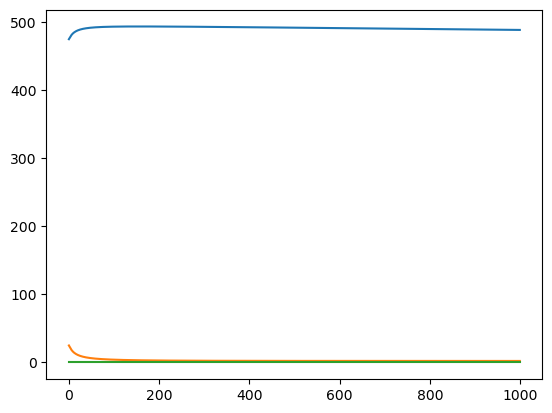

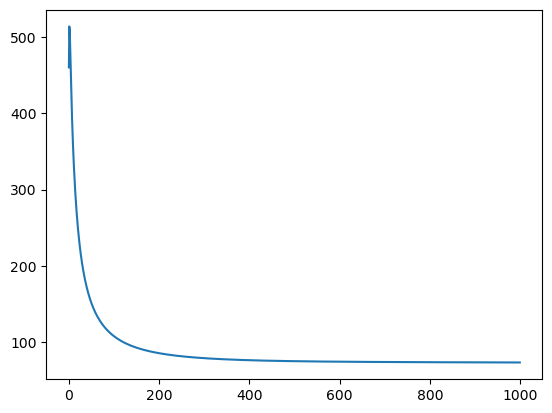

In [ ]:
plt.plot(tvals, xvals)
plt.show()
plt.plot(tvals, uvals)
plt.show()

In [ ]:
u = INITIAL_u2guess
x = INITIAL_X

tvals = list()
xvals = list()
uvals = list()

for steps in tspan_steps:
    t = steps[0]
    # update u based on current state and previous u value
    for j in range(3):
        u = np.array([0])
    # u = control(t, x, u, Q, R, tf, finite=finite)
    # possibly use newton's method?

    # update t, u, x
    tvals.append(t)
    xvals.append(x)
    uvals.append(u)

    # print(evolvex(
    #     t,
    #     x,
    #     u,
    # ))
    
    # solve on each interval, fixing u
    sol = solve_ivp(
        evolvex,
        (steps[0], steps[-1]),
        x,
        args=(u,)
    )

    x = sol.y[:, -1]

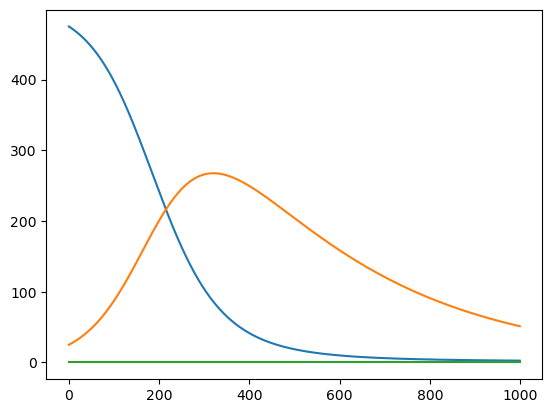

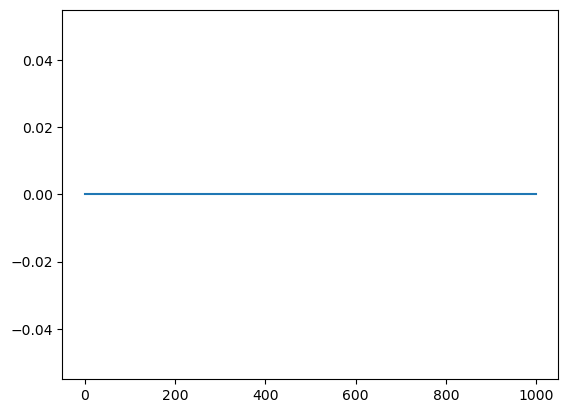

In [ ]:
plt.plot(tvals, xvals)
plt.show()
plt.plot(tvals, uvals)
plt.show()

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.017e+00 ...  1.495e+03  1.500e+03]
        y: [[ 4.750e+02  4.730e+02 ...  2.676e+01  2.679e+01]
            [ 2.500e+01  2.659e+01 ...  8.077e+00  7.925e+00]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]]
      sol: None
 t_events: None
 y_events: None
     nfev: 74
     njev: 0
      nlu: 0

IndexError: index 3 is out of bounds for axis 0 with size 3

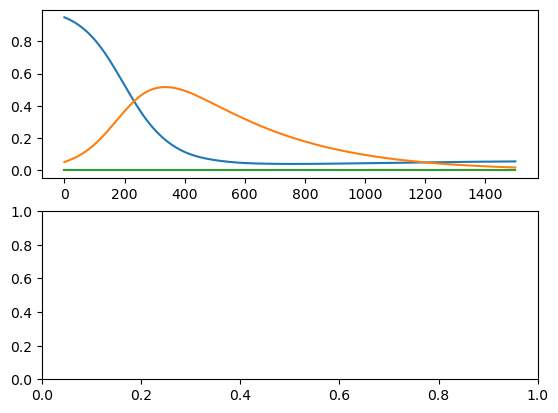

In [ ]:
# solve_ivp params
t0, tf = 0, 1500
tsteps = 300
# y_init = np.concatenate([INITIAL_X, np.array([0])])
y_init = INITIAL_X
# u = [0, 0] # no control
u = [10] # no control

# initialize model
mymod = model.Model(seasonal=False, no_dead=True, params=PARAMS, const_u1=0) # use override parameters

# solve for tf days
sol = solve_ivp(
    mymod.f,
    t_span=[t0, tf],
    y0=y_init,
    t_eval=np.linspace(t0, tf, tsteps),
    args=(u,)
    )

# check convergence and all
display(sol)

# plot
from utils import popplot
popplot(sol, title="Autonomous System Evolution, No Control")